## FineTuning

### Computational Challenges of training LLMs


**CUDA out of memory**

Most of the LLMs are huge and require tons of memory to store and train all parameters. Therefore, there is a high chance that we may come across an out of memory error.


**Approximate the GPU RAM**

1GB = 1024 MB = 1024x1024 KB = 1024x1024x1024 B ~ 109 bytes

1 parameter = 4 bytes (32-bit float) \\
1B parameter = 4x109 bytes = 4GB

So, just to store the model weights of the 1 billion parameter model, we require 4GB of RAM. If we are to train the model, we will have to add others too.


| Variables  | Bytes Per Parameter |
| ---------- | ------------------- |
| Model parameter (Weights) | 4 bytes |
| Adam Optimizer (2 states)  | 8 bytes |
| Gradient | 4 bytes |
| Activation and temporary memory | 8 bytes |
| Total | 4 + 20 extra |

In conclusion, for storing the 1B parameter, we need 4GB @32-bit full precision and for training the model, we need 80GB @32-bit full-precision. So, the training requires 20 times more memory storage than loading the model.

### Quantization

Quantization is one of the options to reduce memory required for training. It is the process of reducing the precision of the weights and activations of a neural network during training or after training. The objective is to decrease the memory requirements and computational cost of the model. It reduces memory required to store model weights by reducing the precision from 32-bit floating point number to 16-bit floating point number or 8-bit or 4-bit integer number.

Quantization often involves moving from floating-point representation to fixed-point representation. In fixed-point representation, a certain number of bits are used to represent the integer part and a certain number of bits for the fractional part.


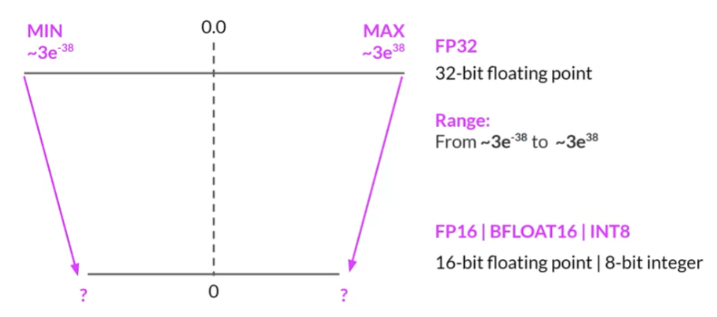

- The datatypes used in deep learning frameworks and libraries are FP32 (32-bit full precision), FP16 or BFLOAT16 (16-bit half precision) and INT8 (8-bit integers).
- The range of numbers we can represent with FP32 is 3x10-38 to 3x1038.
- By default, model weights, activations and other model parameters are stored in 32-bit precision (FP32).
- Quantization statistically projects original 32-bit floating point number into lower precision space using scaling factors calculated based on range of original 32-bit floating point number.


Let’s see how FP32 representation of Pi changes when projected into FP16 lower bit precision space.

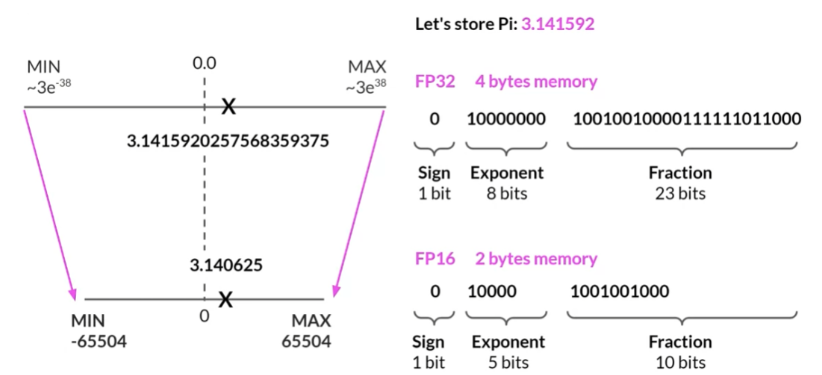

Real value of Pi: 3.141592653589793238462643383279502884197

The range of numbers we can represent with FP16 is vastly smaller from -65504 to 65504. We lose some precision with this projection. Pi value is projected to 3.140625. (only 6 places after the decimal point). This loss is accepted as we are trying to optimize for the memory footprint.

Going from FP32 to FP16, we have reduced the memory requirement by half.

Optimizing the 16 bit quantization, BFLOAT16 has recently become a popular alternative to FP16.


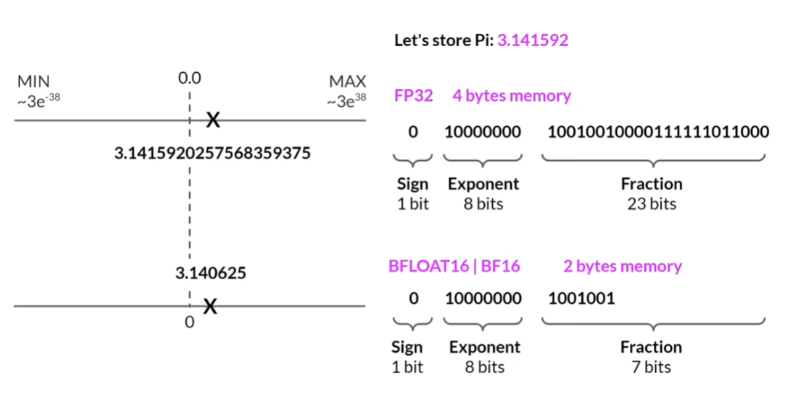

BFLOAT (BF) → Brain Floating point format
- Developed at Google Brain
- Flan-t5 have been trained with BFLOAT16
- Hybrid between FP16 and FP32
- Helps with training stability
- Supported by newer GPU (A100)
- Only truncates the fraction to 7-bits
- Popular choice of precision in deep learning as it maintains the dynamic - range of FP32 but reduces the memory footprint by half


Similarly, for quantizing the Pi from FP32 to INT8,
Pi gets projected to 3 in 8-bit precision space.
This brings the memory requirement from originally 4 bytes to just 1 byte with dramatic loss in precision.


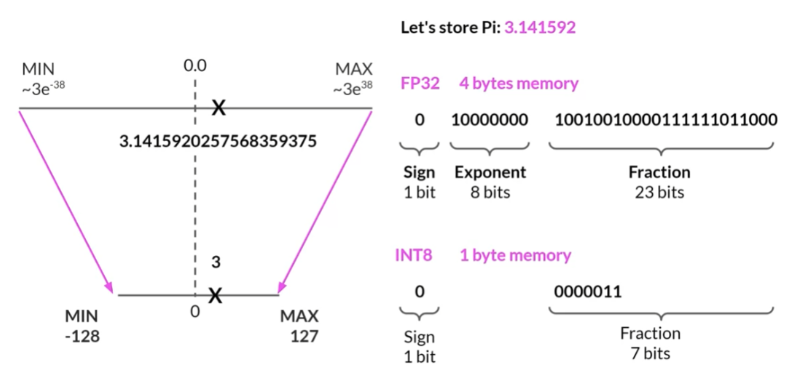

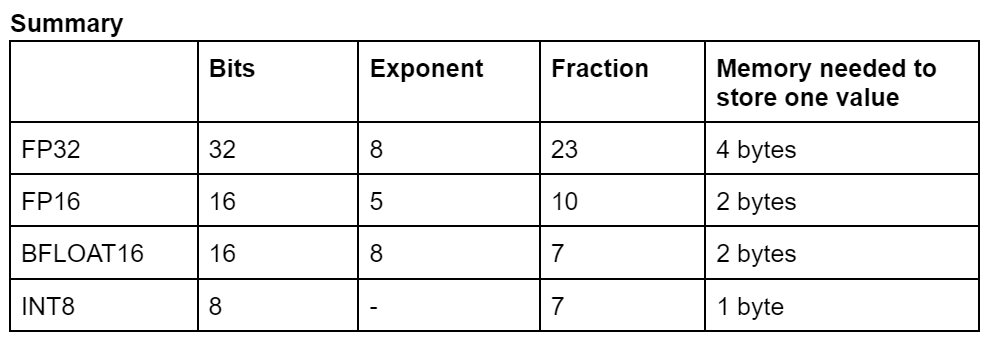

### Scaling laws

Relationship between model size, training configuration and performance in an effort to determine how big the model needs to be.

Goal: maximize the model performance off its learning objective of minimizing loss when predicting tokens

Two options we have to improve the better performance are:
- Increase size of dataset
- Increase number of parameters

In theory, we can increase both of these parameters, however another issue to take into consideration is the compute budget (number of GPUs, time for training models, etc)


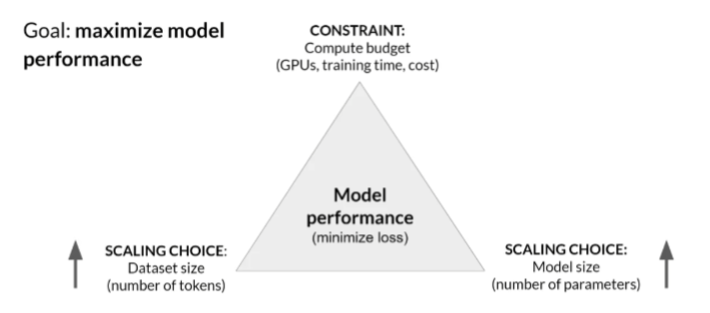

There are well-defined relations between these three scaling choices. Researchers have figured out the trade-offs between dataset size, model size and compute budget.
The compute resources available for training is generally hard constrained (hardware availability, project timeline and financial budget).

By keeping the compute budget fixed, we can use the other two to improve our model performance. The researcher also found out that these two factors show the improved performance with decreasing test loss for increase in their sizes.


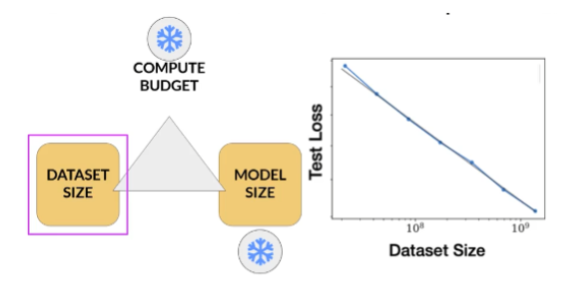

When the compute budget and model size are held fixed and dataset size is varied, then the loss shows that as the dataset size increases the model performance is improved.

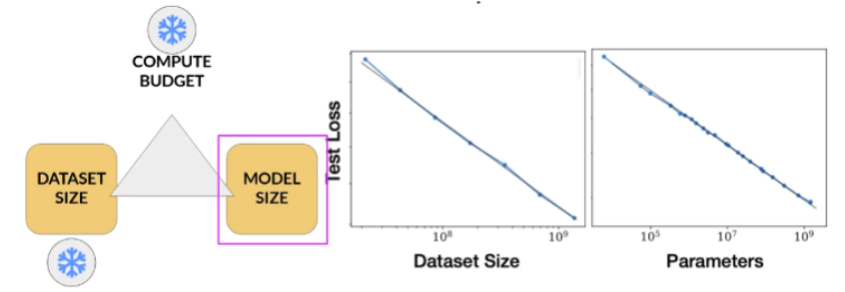

When the compute budget and dataset size are held fixed and model size is varied, then the loss shows that as the model size increases the model performance is improved.

**Compute Optimal Models**

The question arises what is the ideal balance between these three quantities? Are big models always better?

The researcher of the Chinchilla paper carried out a detailed study of the performance of language models of various sizes and quantities of training data with the goal of finding the optimal number of parameters and number of data for a given compute budget.

Findings:
- Very large models may be over-parameterized and under-trained.
  - over-parameterized: more parameters than required to understand the language
  - under-trained: used more training set but trained efficiently only on few
- Smaller models trained on more data could perform as well as large models

Compute optimal training data size is around 20 times greater than the number of parameters.


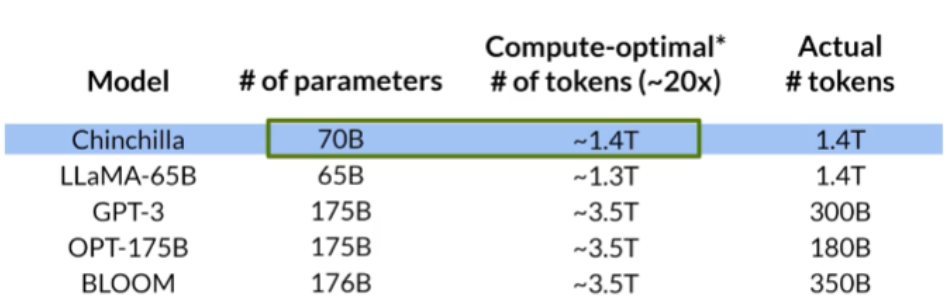

Source:  [link](https://arxiv.org/pdf/2203.15556.pdf)

## Instruction Fine Tuning

When we pretrain the model on huge data that is usually unstructured, then the model learns and encodes a deep statistical representation of language to extract meaningful and valuable features from the text data. But, it doesn’t necessarily know how to respond to prompts (instructions). So, it fails to perform the task we ask it to do. In this situation, further finetuning of the base model to change its behavior of following the instruction can be really helpful.

**Why would we want to finetune a large language model?**

Let's revise the concept of in-context learning that we previously covered in the prompt Engineering. The models learn from the context we provided and perform the tasks accordingly. The smaller model tends to be a poor zero shot learner so we can provide a few examples to guide the response of the language model according to our need. For the complex tasks, even bigger models fail, so that when we provide a few examples the model learns from them and performs the complex tasks too.

But, sometimes even context-learning may not be a good choice.
- In-context learning may not work for smaller models (even when 5-6 examples are included)
- Example takes up space in the context window which ultimately reduces the amount of room we have to include other useful information.


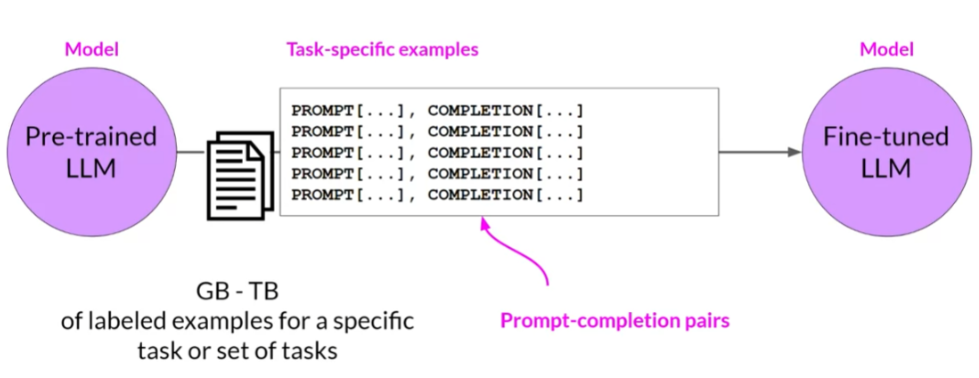

Unlike in pretraining, where there is huge unstructured textual data in the range of GB-TB-PB, fine tuning can be done in small data of GB-TB that has labeled examples for specific tasks. They follow the supervised learning approach. In the above example, prompt and completion are the labeled examples.

Instruction model trains the model using examples that demonstrate how it should respond  to a specific instruction. If we are doing the classification task, then the example of the data could be as shown in the figure below.


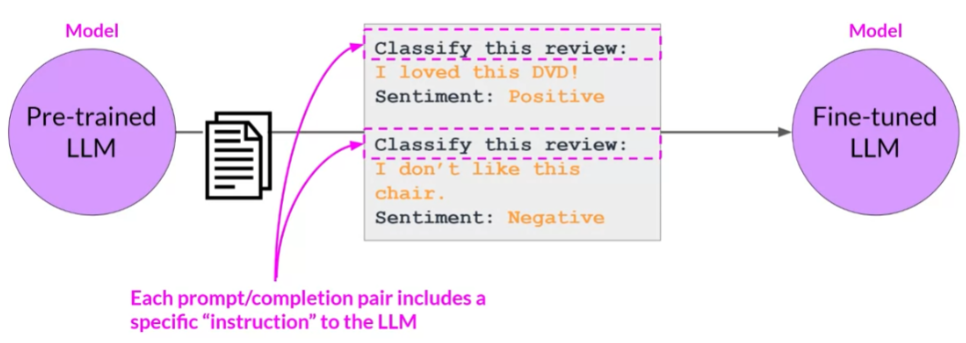

Similarly, if we are performing the task of summarization and translation, then we could use the prompts as:

Summarize the following text: \\
[EXAMPLE TEXT] \\
[EXAMPLE COMPLETION] \\

Translate this sentence to… \\
[EXAMPLE TEXT] \\
[EXAMPLE COMPLETION] \\


**Full Fine Tuning:** Instruction fine tuning where all the model’s weights are updated is known as full fine tuning. This process results in a new version of the model with updated weights. Just like pretraining, full finetune also requires enough memory and compute budget to store and process all the gradient optimizers and other components that are being updated during training.

**Data Preparation**

There are many publicly available dataset that we can leverage but not all are formatted as instructions. In this case, we can use the prompt templates to build the dataset. For example, we can use the Amazon product review data and turn that dataset into instruction based dataset for fine tuning.


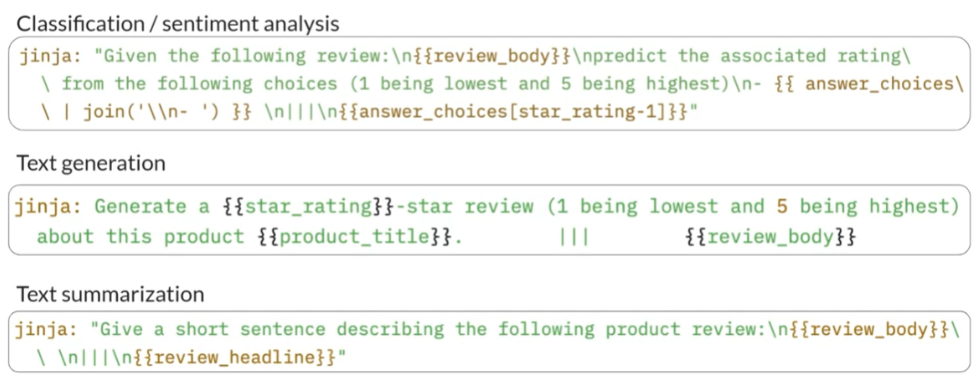

Then, after creating the data we can follow the normal Machine Learning workflow of splitting into training, validation and test datasets.

**Fine Tuning on a single Task**

By default as the way LLM are pretrained, they are capable of performing various language tasks based on their parameters size and their level of understanding and how efficiently they are trained. But, sometimes our application may only need to perform a single task (example, summarization, translation, etc). In this case, we can fine tune the model on only the task we are interested in. For this, around 1,000 examples are enough to train the model as it has already learned many other language patterns during the pre-training step.


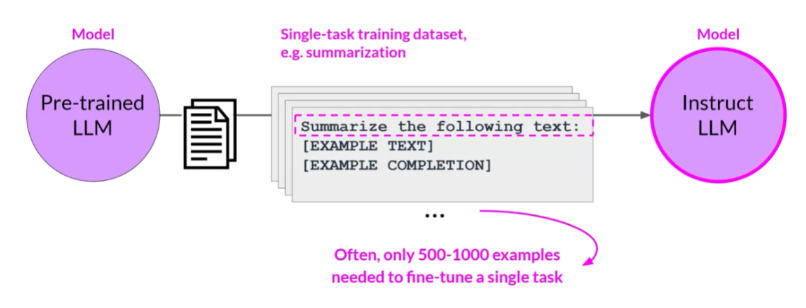

**Drawback of Single-Task Fine Tuning**

While the full finetuning on a single task may lead to great performance on that particular task, it may degrade the performance of the original model to perform the task on other tasks. Because full-finetuning modifies all weights of original LLM, it degrades the performance on other tasks that the model originally was capable of. The model forgets to do other tasks and this is known as **catastrophic forgetting.**

**How to avoid catastrophic forgetting?**

- Based on our necessity, if we only need a model to perform one specific task and we are fine letting the model forget about the other. Then, we may not need to avoid catastrophic forgetting. If we want and need to maintain the model’s multi task generalizing capabilities, then we can perform full fine tuning on multiple tasks at the same time. But, this requires a lot of datasets of around 50-100k examples across all tasks.

- We can perform Parameter Efficiënt Fine Tuning (PEFT) instead of full finetuning. This preserves the weights of original LLM and trains only a small number of task specific adapters, layers and parameters. Here, most of the pre-trained weights are left unchanged.  
We will talk more about PEFT in the upcoming contents.


**Multi-task Fine Tuning**

We use the mixed dataset that is composed of many tasks so that model performance can be improved on all the tasks simultaneously avoiding the issue of catastrophic forgetting. It requires a lot of training data and compute resources also.


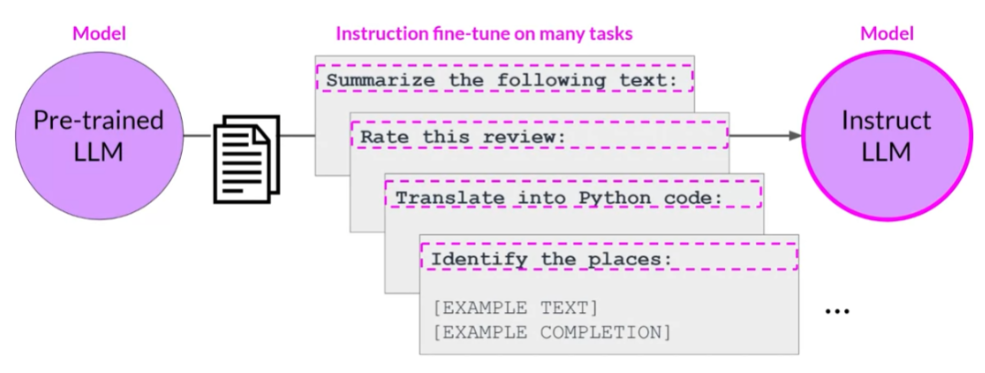

Examples of multi-task fine tuned models are FLAN-T5, FLAN-PALM which are instruction fine tuned with the base model T5 and PALM respectively.

FLAN-T5 is a great general purpose instruct model fine tuned on 473 datasets across 146 task categories. One example dataset is a SAMSum dataset used to train for the dialogue summarization tasks.


## PEFT

Fine-tuning the pretrained LLMs on downstream datasets results in huge performance gains when compared to using the pretrained LLMs out-of-the-box. However, as models get larger and larger, full fine-tuning becomes infeasible to train on consumer hardware. In addition, storing and deploying fine-tuned models independently for each downstream task becomes very expensive, because fine-tuned models are the same size as the original pretrained model. So to address the problems a approach called Parameter-Efficient Fine-tuning (PEFT) is introduced.

Parameter-Efficient Fine-Tuning (PEFT) methods enable efficient adaptation of pre-trained language models (PLMs) to various downstream applications without fine-tuning all the model's parameters. PEFT methods only update a small subset of (extra) model parameters, significantly decreasing computational and storage costs.

Some PEFT techniques freeze most of the model weights and fine tune subsets of model parameters while other techniques don’t touch the original model weights at all, but instead add a small number of new parameters/layers and fine tune only the new components.

With PEFT, most if not all LLM weights are kept frozen. As a result, the number of trained parameters is much smaller than the number of parameters in the original LLM. This makes memory requirements for training managed. PEFT can often be performed in a single GPU.

In short, PEFT approaches enable you to get performance comparable to full fine-tuning while only having a small number of trainable parameters. As only some weights are only changed, it is less prone to catastrophic forgetting, a behavior observed during the full finetuning of LLMs. Recent state-of-the-art PEFT techniques achieve performance comparable to that of full fine-tuning.


## PEFT Methods

The methods in Parameter-Efficient Fine-Tuning (PEFT) are mainly differentiated based on the usage of the original LLM parameters or addition of the new parameters to the original LLM.

1. Use original LLM parameters
  - **Selective:** We select the initial LLM parameters to finetune.
  - **Reparameterization:** We reparameterize model weights using low-rank representations. We reduce the number of parameters to train creating new low rank transformations of the original network weights. Example: LoRA
2. Additive
In this method, we add trainable layers/parameters to the original model freezing all original LLM weights.
  - **Adapter method:** In this, we add new trainable layers to the architecture of the model typically inside encoder or decoder components after attention or feed forward layers.
  - **Soft Prompt:** In this, we keep the model architecture fixed and frozen and focus on manipulating the input to achieve better performance. Prompt Tuning is one of the soft prompt techniques.


## PEFT Techniques

### LoRA

**Problem with fine-tuning**

- We must train a full network, which is computationally expensive for the average user when dealing with LLM like GPT.
- Storage requirements for the checkpoints are expensive, as we need to save the entire model on the disk for each checkpoint. If we also save the optimizer state (which we usually do, then the situation gets worse!)
- If we have multiple fine-tuned models, we need to reload all the weights of the model every time we want to switch between them, which can be expensive and slow. For example, we may have a model fine-tuned for helping users write SQL queries and one model for helping users write Javascript code.

Low-Rank Adaptation (LoRA) reduces the number of trainable parameters by learning pairs of rank-decomposition matrices while freezing the original weights. This vastly reduces the storage requirement for large language models adapted to specific tasks and enables efficient task-switching during deployment all without introducing inference latency. It adds pairs of rank-decomposition weight matrices (called update matrices) to existing weights, and only trains those newly added weights. LoRA also outperforms several other adaptation methods including adapter, prefix-tuning, and fine-tuning.

Steps while Finetuning:
1. Freeze most of the original LLM weights
2. Inject 2 rank decomposition matrices \\
  **Note:** dimension of smaller matrix are set such that their product is a matrix with the same dimensions as the weight they are modifying (original LLM frozen)


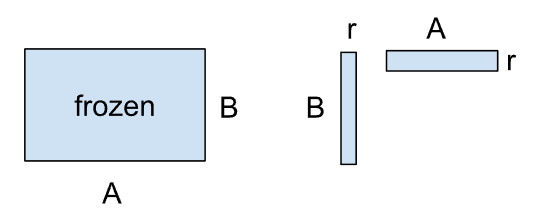

Here AxB is the original LLM weight which can be decomposed into Bxr and rxA matrices with the rank of r.

3. Train the weights of the smaller matrices.

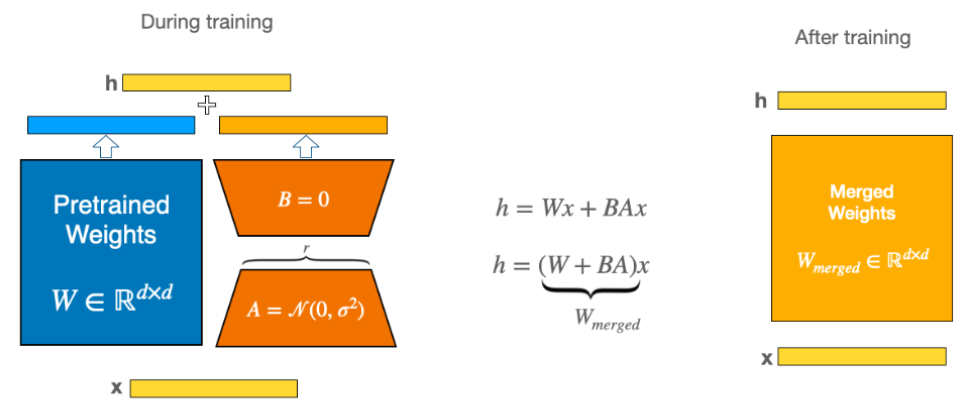

Steps to update model for inference:

1. Matrix multiply the low rank matrices


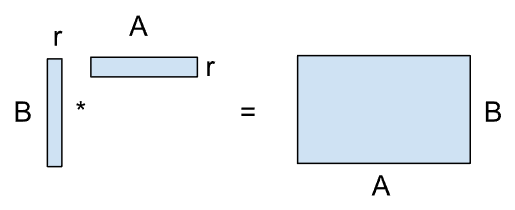

2. Add to original weights.


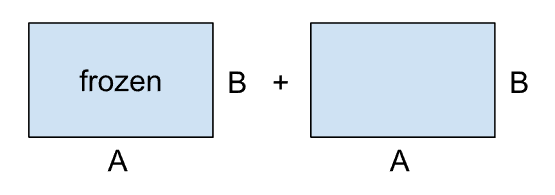

As an example, in the original transformer paper, the transformer weights have dimensions of dxk = 512x64. So, 512x64 = 32,768 trainable parameters.

In LoRA, with rank r = 8, \\
A has dimensions rxk=8x64=512 parameters \\
B has dimensions dxr=52x8=4096 parameters \\
This totals to 4608 trainable parameters. \\

Applying LoRA to just the self-attention layer of the model is often enough to fine tune for a task and achieve performance gain as most of the parameters of models are in the attention layer.

Also, the ways to choose the best rank of LoRA matices is still in research. But smaller the rank, smaller the trainable parameters and more savings on compute. According to the experiments in the original paper, choosing a greater rank doesn’t mean improved performance.

**Benefits of using LoRA**
- There will be less parameters to train and store with lower rank to decompose the original weight into much smaller matrices.
- It enables faster backpropagation, as we do not need to evaluate the gradient for most of the parameters as original pre-trained weights are kept frozen.
- LoRA facilitates the easy switch between two different fine-tuned models just by changing the parameters of the A and B matrices instead of reloading the W matrix again.
- LoRA does not add any inference latency because adapter weights can be merged with the base model.


### Prefix Tuning

It is a lightweight alternative to fine-tuning for natural language generation tasks, which keeps language model parameters frozen and instead optimizes a sequence of continuous task-specific vectors, which we call the prefix. Prefix-tuning draws inspiration from prompting for language models, allowing subsequent tokens to attend to this prefix as if it were “virtual tokens”.

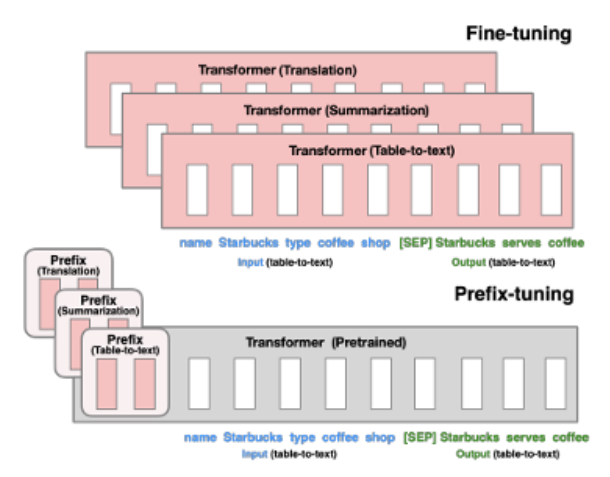

In this approach, if we are to perform the full finetuning then we have to update all language model parameters represented in red boxes in the upper figure and require storing a full model copy for each task. But, if we are to use the prefix tuning, we freeze the language model parameters and only optimize the prefixes in red boxes in the bottom figure. Different prefixes are trained for different tasks. Doing this, we only need to store the prefix for each task making prefix tuning modular and space-efficient.

The paper shows two tasks using the prefix tuning: table-to-text generation using GPT-2 and summarization using BART. On both table-to-text and summarization, prefix tuning extrapolates better than fine-tuning under all metrics. They also found that adapter-tuning also achieves good extrapolation performance, comparable with prefix-tuning.


### Adapter Tuning

Fine-tuning large pre-trained models is an effective transfer mechanism in NLP. However, in the presence of many downstream tasks, fine-tuning is parameter inefficient: an entire new model is required for every task. So, the transfer of the knowledge with the adapter modules was introduced. They add only a few trainable parameters per task, and new tasks can be added without revisiting previous ones. The parameters of the original network remain fixed, yielding a high degree of parameter sharing. Adapters attain near state-of-the-art performance, whilst adding only a few parameters per task.


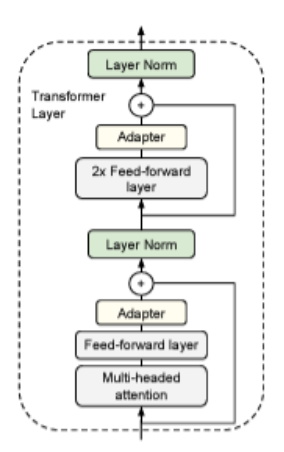

In the paper, they add the adapter module twice to each transformer layer: after the projection following multi-headed attention and after the two feed-forward layers. This tuning method helps to attain good performance by adding only a small number of additional parameters per task.

When performing vanilla fine-tuning of deep networks, a modification is made to the top layer of the network.This is required because the label spaces and losses for the upstream and downstream tasks differ. Adapter modules perform more general architectural modifications to repurpose a pretrained network for a downstream task. In particular, the adapter tuning strategy involves injecting new layers into the original network.The weights of the original network are untouched, whilst the new adapter layers are initialized at random. In standard fine-tuning, the new top-layer and the original weights are co-trained. In contrast, in adapter tuning, the parameters of the original network are frozen and therefore may be shared by many tasks.


### Prompt Tuning


If the task we are trying to perform is really complex, then we may need to provide many dozens of examples in the prompt while doing prompt engineering which is really ineffective. So, hand crafted prompts are replaced by AI prompts known as soft prompts.  Soft prompts have shown to outperform human engineered prompts which are also known as Hard prompts (hard-coded by humans).

Soft prompts are used in prompt tuning which are not recognizable to the human eye. Each prompt consists of an embedding (strings of numbers) that distill knowledge from larger models. Soft prompts can be task-specific and act as a substitute for the additional training data. They are effective for guiding the models into desired output.


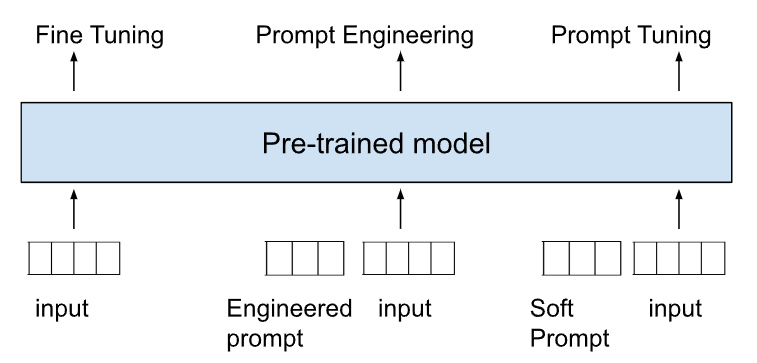

The above diagram shows the high level difference between fine tuning, prompt engineering and prompt tuning. In the above diagram, inputs are the examples that the model learns from. Engineered prompt is the extra set of instructions that prompt engineer craft to make the model instruct to do a certain task by giving the input and the corresponding output. Soft prompts are the tokens that are to be trained while fine tuning.

Prompt tuning is proven to be a game changer in the variety of areas, especially multi-task learning where models need to quickly switch between tasks finding ways to create universal prompts (multi-task prompt tuning). Prompt Tuning is also showing promise in the field of continual learning, where AI models need to learn new tasks without forgetting the old ones.Prompt Tuning allows your model to adapt to specialized tasks faster than fine tuning and prompt engineering.


**Sources**

Adapter Tuning: https://arxiv.org/pdf/1902.00751.pdf \\
Prefix Tuning:https://aclanthology.org/2021.acl-long.353.pdf \\
Prefix Tuning (v2): https://arxiv.org/pdf/2110.07602.pdf \\
P-Tuning:  https://arxiv.org/pdf/2103.10385.pdf \\
Prompt Tuning: https://arxiv.org/pdf/2104.08691.pdf \\
https://arxiv.org/pdf/2110.07602.pdf \\


PEFT:
https://huggingface.co/blog/peft \\
https://arxiv.org/pdf/2205.05638.pdf \\
https://arxiv.org/pdf/2305.16742.pdf \\

LoRA: https://arxiv.org/pdf/2106.09685.pdf \\
QLoRA: https://arxiv.org/pdf/2305.14314.pdf